In [2]:
# import packages

In [2]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
from scipy.stats import pearsonr
import nibabel as nib
import gc
import pingouin as pg
import statsmodels.api as sm
from statsmodels.formula.api import ols
from scipy.stats import pearsonr, zscore
import pingouin as pg

subject_list=np.loadtxt("/path/to/subject_list.txt", delimiter=",", dtype=str)

In [4]:
# get roi betas

In [ ]:
final_atlas_aligned = nib.load("path/to/Schaefer2018_space-fsLR_den-91k_desc-200Parcels17Networks_dseg.dlabel.nii")

pixdim[1,2,3] should be non-zero; setting 0 dims to 1


In [ ]:
mask_dmn_a = ((final_atlas_aligned >= 75) & (final_atlas_aligned <= 82))|((final_atlas_aligned >= 184) & (final_atlas_aligned <= 189))
mask_dmn_b = ((final_atlas_aligned >= 83) & (final_atlas_aligned <= 95))|((final_atlas_aligned >= 190) & (final_atlas_aligned <= 193))
mask_dmn_c = ((final_atlas_aligned >= 96) & (final_atlas_aligned <= 98))|((final_atlas_aligned >= 194) & (final_atlas_aligned <= 196))
np.save("/path/mask_dmn_a",mask_dmn_a)
np.save("/path/mask_dmn_b",mask_dmn_b)
np.save("/path/mask_dmn_c",mask_dmn_c)

In [ ]:
for sub in subject_list:
    for run in range(1,10):
        one_run = nib.load(f"/path/to/sub-{sub}/sub-{sub}_task-ers_run-{run}_space-fsLR_den-32k_desc-sm2pt0_beta.dscalar.nii").get_fdata()
        surface = one_run
        if run == 1:
            data = surface
        else:
            data = np.concatenate([data,surface], axis=0)
    for roi in ["dmn_a","dmn_b","dmn_c"]:
        mask = np.load(f"/path/mask_{roi}.npy")
        network = data[:,mask]
        np.save(f"/path/to/sub-{sub}_{roi}2", network)

In [ ]:
# compute indexes for RSA

In [ ]:
# still no exclusion here, it could later be done, not now.
all_events = pd.read_csv("/path/to/all_events.csv",index_col="global_index")
index_df =  all_events.copy()
index_df[['E_pair','S_pair','R_pair','E_baseline','S_baseline','R_baseline']] = None
for i in all_events.index:
    trial_type = all_events.loc[i,"trial_type"]
    sub = all_events.loc[i,"sub_id"]
    stim = all_events.loc[i,"stim_id"]
    run = all_events.loc[i,"run_id"]

    pair_enc = all_events[(all_events["sub_id"]==sub)&(all_events["trial_type"] == "enc")&(all_events["stim_id"]==stim)].index
    enc_baseline = all_events[(all_events["sub_id"]==sub)&(all_events["trial_type"] == "enc")&(all_events["stim_id"]!=stim)&(all_events["run_id"]==run)].index
    pair_ret = all_events[(all_events["sub_id"]==sub)&(all_events["trial_type"] == "ret")&(all_events["stim_id"]==stim)].index
    ret_baseline = all_events[(all_events["sub_id"]==sub)&(all_events["trial_type"] == "ret")&(all_events["stim_id"]!=stim)&(all_events["run_id"]==run)].index
    pair_sim = all_events[(all_events["sub_id"]==sub)&(all_events["trial_type"] == "sim")&(all_events["stim_id"]==stim)].index
    sim_baseline = all_events[(all_events["sub_id"]==sub)&(all_events["trial_type"] == "sim")&(all_events["stim_id"]!=stim)&(all_events["run_id"]==run)].index
    
    if len(pair_ret) ==0:
           next
    else:
       index_df.loc[i,'R_pair'] = pair_ret
       index_df.at[i,'R_baseline'] = ret_baseline
        
    if len(pair_enc) ==0:
        next
    else:
        index_df.loc[i,'E_pair'] = pair_enc
        index_df.at[i,'E_baseline'] = enc_baseline

    if len(pair_sim) ==0:
        next
    else:
        index_df.loc[i,'S_pair'] = pair_sim
        index_df.at[i,'S_baseline'] = sim_baseline

In [ ]:
# make the calculations

In [ ]:
all_rois = dict()

for sub in subject_list:
    subject_data = dict()
    for roi in ["dmn_a","dmn_b","dmn_c"]:
        subject_data[f"{roi}_data"] = np.load(f"/path/to/sub-{sub}_{roi}.npy")
        if sub == "001":
            all_rois[f"all_{roi}"] = subject_data[f"{roi}_data"] 
        else:
            all_rois[f"all_{roi}"] = np.concatenate((all_rois[f"all_{roi}"], subject_data[f"{roi}_data"]))

In [ ]:
for roi in ["dmn_a","dmn_b","dmn_c"]:
    data = all_rois[f"all_{roi}"]
    results = index_df.copy()
    for i in index_df.index:
        this_trial = data[i]
        
        e_pair = data[index_df.loc[i,'E_pair'][0]]
        e_base = data[index_df.loc[i,'E_baseline']]
        e_basesim = [pearsonr(this_trial, v)[0] for v in e_base]
        to_e = pearsonr(this_trial, e_pair)[0]
        if to_e > 0.99999:
            to_e = None
        else:     
            e_baseline = np.mean(np.arctanh(e_basesim))
            to_e = np.arctanh(pearsonr(this_trial, e_pair)[0])
            results.loc[i,f'to_e_{roi}'] = to_e - e_baseline

        r_pair = data[index_df.loc[i,'R_pair'][0]]
        r_base = data[index_df.loc[i,'R_baseline']]
        r_basesim = [pearsonr(this_trial, v)[0] for v in r_base]
        to_r = pearsonr(this_trial, r_pair)[0]
        if to_r > 0.99999:
            to_r = None
        else:     
            r_baseline = np.mean(np.arctanh(r_basesim))
            to_r = np.arctanh(pearsonr(this_trial, r_pair)[0])
            results.loc[i,f'to_r_{roi}'] = to_r - r_baseline


        s_pair = data[index_df.loc[i,'S_pair'][0]]
        s_base = data[index_df.loc[i,'S_baseline']]
        s_basesim = [pearsonr(this_trial, v)[0] for v in s_base]
        to_s = pearsonr(this_trial, s_pair)[0]
        if to_s > 0.99999:
            to_s = None
        else:     
            s_baseline = np.mean(np.arctanh(s_basesim))    
            to_s = np.arctanh(pearsonr(this_trial, s_pair)[0])
            results.loc[i,f'to_s_{roi}'] = to_s - s_baseline
    print(roi,"done")
    results.to_csv(f"path/to/results_{roi}.csv")

sommotb done


In [ ]:
# clean up the results

In [ ]:
# curate the results
rsa_abc = pd.DataFrame()
for roi in ["dmn_a","dmn_b","dmn_c"]:
    results_roi = pd.read_csv(f"/path/to/results_{roi}.csv")
    exclude_specific = (results_roi['sub_id'] == "sub-023") & (results_roi['run_id'] == "run-04")
    results_roi_clean = results_roi[~exclude_specific]
    results_roi_clean["sr_similarity"] = np.select([results_roi_clean["trial_type"]=="sim",results_roi_clean["trial_type"]!="sim"], [results_roi_clean[f"to_r_{roi}"], np.nan])
    results_roi_clean["se_similarity"] = np.select([results_roi_clean["trial_type"]=="sim",results_roi_clean["trial_type"]!="sim"], [results_roi_clean[f"to_e_{roi}"], np.nan])
    results_roi_clean["er_similarity"] = np.select([results_roi_clean["trial_type"]=="ret",results_roi_clean["trial_type"]!="ret"], [results_roi_clean[f"to_e_{roi}"], np.nan])
    roi_sub = results_roi_clean[["task_order","sub_id","sr_similarity","se_similarity","er_similarity"]].groupby(["sub_id","task_order"]).mean().reset_index()
    roi_sub['roi'] = roi
    rsa_abc = pd.concat([rsa_abc,roi_sub], ignore_index=True)

rsa_abc["task_order_2"]=np.select([rsa_abc["task_order"]=="S-E-R",rsa_abc["task_order"]!="S-E-R"],["Sim-First","Sim-After"])

/tmp/ipykernel_2788595/1683829149.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_roi_clean["sr_similarity"] = np.select([results_roi_clean["trial_type"]=="sim",results_roi_clean["trial_type"]!="sim"], [results_roi_clean[f"to_r_{roi}"], np.nan])
/tmp/ipykernel_2788595/1683829149.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_roi_clean["se_similarity"] = np.select([results_roi_clean["trial_type"]=="sim",results_roi_clean["trial_type"]!="sim"], [results_roi_clean[f"to_e_{roi}"], np.na

In [ ]:
# stats tests

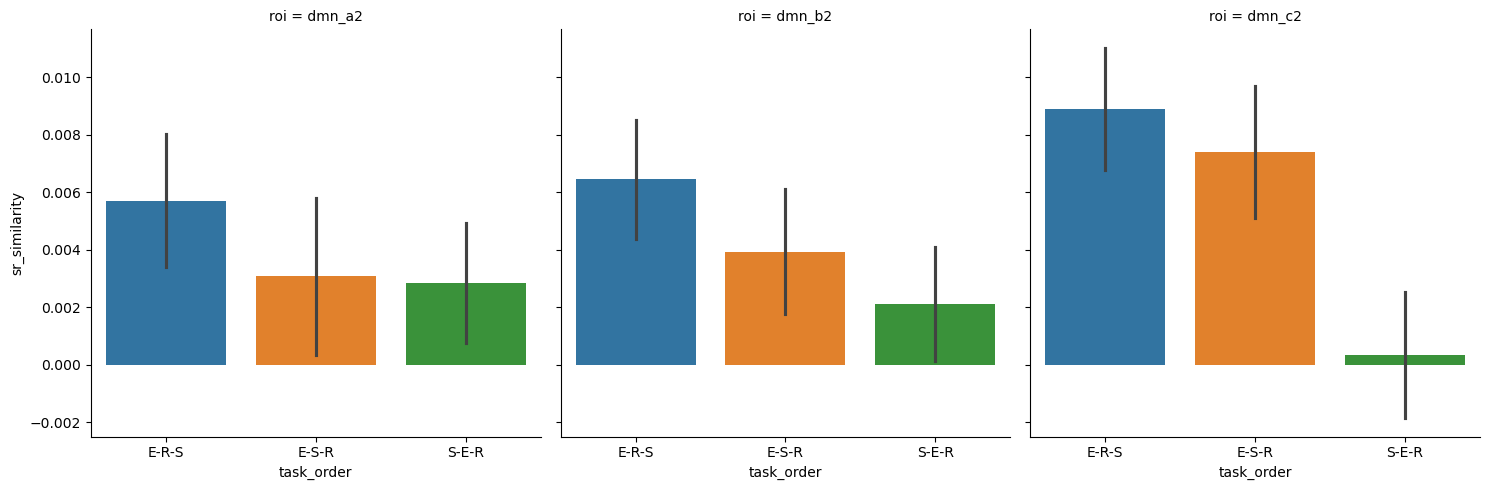

In [4]:
sns.catplot(data=rsa_abc, x='task_order', y='sr_similarity', hue='task_order', col = 'roi', errorbar ='se', kind="bar")

In [6]:
model = ols('sr_similarity~ C(task_order)*C(roi)', data=rsa_abc).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print(anova_table)

                        sum_sq     df         F    PR(>F)
C(task_order)         0.001456    2.0  4.187304  0.016066
C(roi)                0.000168    2.0  0.482882  0.617472
C(task_order):C(roi)  0.000511    4.0  0.734281  0.569160
Residual              0.053218  306.0       NaN       NaN


In [8]:
posthocs = pg.pairwise_tests(
    data=rsa_abc, 
    dv='sr_similarity', 
    within=['roi', 'task_order'],          
    subject='sub_id',
    return_desc=True )


posthocs

,Contrast,roi,A,B,mean(A),std(A),mean(B),std(B),Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,roi,-,dmn_a2,dmn_b2,0.003879,0.007347,0.004174,0.007958,True,True,-0.224282,34.0,two-sided,0.823880,0.186,-0.038008
1,roi,-,dmn_a2,dmn_c2,0.003879,0.007347,0.005554,0.007532,True,True,-1.154138,34.0,two-sided,0.256492,0.334,-0.222643
2,roi,-,dmn_b2,dmn_c2,0.004174,0.007958,0.005554,0.007532,True,True,-0.956906,34.0,two-sided,0.345370,0.277,-0.176231
3,task_order,-,E-R-S,E-S-R,0.007021,0.008949,0.004811,0.011509,True,True,0.923940,34.0,two-sided,0.362029,0.269,0.212044
4,task_order,-,E-R-S,S-E-R,0.007021,0.008949,0.001775,0.010281,True,True,2.085987,34.0,two-sided,0.044554,1.237,0.538227
5,task_order,-,E-S-R,S-E-R,0.004811,0.011509,0.001775,0.010281,True,True,1.216563,34.0,two-sided,0.232149,0.357,0.275054
6,roi * task_order,dmn_a2,E-R-S,E-S-R,0.005705,0.013680,0.003078,0.016066,True,True,0.730669,34.0,two-sided,0.469987,0.232,0.174083
7,roi * task_order,dmn_a2,E-R-S,S-E-R,0.005705,0.013680,0.002854,0.012409,True,True,0.877868,34.0,two-sided,0.386177,0.259,0.215845
8,roi * task_order,dmn_a2,E-S-R,S-E-R,0.003078,0.016066,0.002854,0.012409,True,True,0.059807,34.0,two-sided,0.952660,0.182,0.015426
9,roi * task_order,dmn_b2,E-R-S,E-S-R,0.006457,0.012200,0.003945,0.012946,True,True,0.867022,34.0,two-sided,0.392008,0.257,0.197533
